# DSP Foundations Examples: Controlled Experiments For Condition Monitoring

This notebook is a concept laboratory. Every example is synthetic so that the signal content is known before the analysis is run.

## Learning Objectives

- Relate waveform shape to interpretable time-domain features such as RMS, crest factor, and kurtosis.
- Explain FFT, PSD, Nyquist limits, aliasing, spectral leakage, and time-frequency localization.
- Connect tones, impacts, modulation, and transients to realistic condition-monitoring questions.
- Separate an engineering observation from a physical hypothesis and its limitations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal as scipy_signal

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from signal_processing_prep.features import FeatureExtractor, FrequencyBand, SlidingWindowConfig
from signal_processing_prep.frequency_domain import (
    band_energy,
    dominant_frequency,
    fft_magnitude,
    psd,
    spectral_bandwidth,
    spectral_centroid,
    spectral_flatness,
    spectral_rolloff,
)
from signal_processing_prep.plotting import (
    plot_frequency_spectra,
    plot_hilbert_huang_imfs,
    plot_hilbert_huang_spectrum,
    plot_spectral_kurtosis,
    plot_teager_kaiser_energy,
    plot_teager_kaiser_frequency,
    plot_time_signal,
)
from signal_processing_prep.records import SignalRecord
from signal_processing_prep.synthetic import (
    add_signals,
    chirp_signal,
    damped_resonant_impact_train,
    impulse_train,
    noisy_sine_wave,
    sine_wave,
    transient_burst,
)
from signal_processing_prep.time_domain import crest_factor, kurtosis, rms, skewness, zero_crossing_rate
from signal_processing_prep.time_frequency import (
    discrete_wavelet_analysis,
    hilbert_analysis,
    hilbert_huang_transform,
    morlet_wavelet_scalogram,
    spectral_kurtosis,
    stft_analysis,
    teager_kaiser_demodulation,
)

print(f"Using repository root: {repo_root}")

Using repository root: C:\Users\jonas\software_development\signal_processing_prep


In [2]:
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
        print("Using matplotlib widget backend.")
    except Exception:
        ip.run_line_magic("matplotlib", "inline")
        print("Widget backend unavailable; using inline plots.")

Using matplotlib widget backend.


## 1. Controlled Signal Set

The examples below change one signal characteristic at a time: noise, additional periodic content, impacts, short resonant bursts, and frequency variation.

In [3]:
sampling_rate_hz = 2000.0
duration_seconds = 4.0

base_sine = sine_wave(frequency_hz=50.0, duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, amplitude=1.0, name="50_hz_sine")
noisy_sine = noisy_sine_wave(frequency_hz=50.0, duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, amplitude=1.0, noise_std=0.25, seed=7, name="50_hz_noisy_sine")
two_tone = add_signals(
    [
        sine_wave(frequency_hz=50.0, duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, amplitude=1.0, name="50_hz_component"),
        sine_wave(frequency_hz=180.0, duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, amplitude=0.35, name="180_hz_component"),
    ],
    label="two_tone",
    name="50_180_hz_two_tone",
)
impulses = impulse_train(duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, impulse_rate_hz=20.0, amplitude=1.0, name="20_hz_impulse_train")
burst = transient_burst(duration_seconds=duration_seconds, sampling_rate_hz=sampling_rate_hz, burst_frequency_hz=450.0, burst_start_seconds=0.8, burst_duration_seconds=0.08, amplitude=1.0, name="450_hz_transient_burst")
chirp = chirp_signal(start_frequency_hz=30.0, end_frequency_hz=350.0, duration_seconds=3.0, sampling_rate_hz=4000.0, name="30_to_350_hz_chirp")
bearing_impacts = damped_resonant_impact_train(
    duration_seconds=1.2,
    sampling_rate_hz=12800.0,
    impact_rate_hz=5.0,
    first_impact_seconds=0.14,
    resonance_frequency_hz=2400.0,
    ringdown_duration_seconds=0.018,
    decay_time_constant_seconds=0.0035,
    impact_amplitude=1.0,
    background_frequency_hz=35.0,
    background_amplitude=0.08,
    noise_std=0.025,
    seed=11,
    name="bearing_like_damped_impacts",
)

records = [base_sine, noisy_sine, two_tone, impulses, burst, bearing_impacts]
pd.DataFrame(
    [
        ("Pure sine", "single periodic component", "shaft-speed-related tone"),
        ("Noisy sine", "degraded SNR", "noisy acquisition"),
        ("Two-tone signal", "component separation", "multiple machine components"),
        ("Impulse train", "sparse repeated impacts", "repetitive contact defect"),
        ("Transient burst", "localized high-frequency energy", "impact-excited resonance"),
        ("Damped impacts", "repeated multiscale ring-downs", "bearing-like localized defect"),
        ("Chirp", "changing frequency", "speed ramp or run-up"),
    ],
    columns=["Signal", "Educational concept", "Monitoring analogy"],
)

,Signal,Educational concept,Monitoring analogy
0,Pure sine,single periodic component,shaft-speed-related tone
1,Noisy sine,degraded SNR,noisy acquisition
2,Two-tone signal,component separation,multiple machine components
3,Impulse train,sparse repeated impacts,repetitive contact defect
4,Transient burst,localized high-frequency energy,impact-excited resonance
5,Damped impacts,repeated multiscale ring-downs,bearing-like localized defect
6,Chirp,changing frequency,speed ramp or run-up


## 2. Known-Signal Checkpoints

Before interpreting unknown data, verify the tools against a signal with known answers. For a unit-amplitude sine wave, RMS is $1 / \sqrt{2}$ and crest factor is $\sqrt{2}$.

In [4]:
checkpoint_rows = [
    ("RMS", 1.0 / np.sqrt(2.0), rms(base_sine)),
    ("Crest factor", np.sqrt(2.0), crest_factor(base_sine)),
    ("Dominant frequency [Hz]", 50.0, dominant_frequency(fft_magnitude(base_sine))),
]
checkpoint_table = pd.DataFrame(checkpoint_rows, columns=["Metric", "Expected", "Computed"])
checkpoint_table["Absolute error"] = (checkpoint_table["Computed"] - checkpoint_table["Expected"]).abs()
checkpoint_table

,Metric,Expected,Computed,Absolute error
0,RMS,0.707107,0.707107,0.0
1,Crest factor,1.414214,1.414214,0.0
2,Dominant frequency [Hz],50.000000,50.000000,0.0


**Observation:** the calculation reproduces analytically known values for the clean tone. **Interpretation:** subsequent feature changes can be linked to deliberate changes in the signal. **Limitation:** real sensor amplitudes need calibration and acquisition context before obtaining physical meaning.

## 3. Time-Domain Behavior

RMS captures typical amplitude; crest factor and kurtosis respond strongly to impulsive behavior; zero-crossing rate gives a rough indication of rapid oscillation or noisy texture.

In [5]:
time_domain_df = pd.DataFrame(
    [
        {
            "name": record.name,
            "rms": rms(record),
            "crest_factor": crest_factor(record),
            "zero_crossings_per_second": zero_crossing_rate(record),
            "skewness": skewness(record),
            "kurtosis": kurtosis(record),
        }
        for record in records
    ]
)
time_domain_df

,name,rms,crest_factor,zero_crossings_per_second,skewness,kurtosis
0,50_hz_sine,0.707107,1.414214,99.762470,-2.556590e-16,1.499812
1,50_hz_noisy_sine,0.747912,2.544362,189.273659,5.389214e-03,1.810152
2,50_180_hz_two_tone,0.749166,1.779138,119.764971,-1.204265e-16,1.791660
3,20_hz_impulse_train,0.100000,10.000000,0.000000,9.851218e+00,98.070259
4,450_hz_transient_burst,0.100000,10.000000,18.002250,1.138192e-15,75.045771
5,bearing_like_damped_impacts,0.090545,10.546302,1610.104825,-3.003462e-01,25.689240


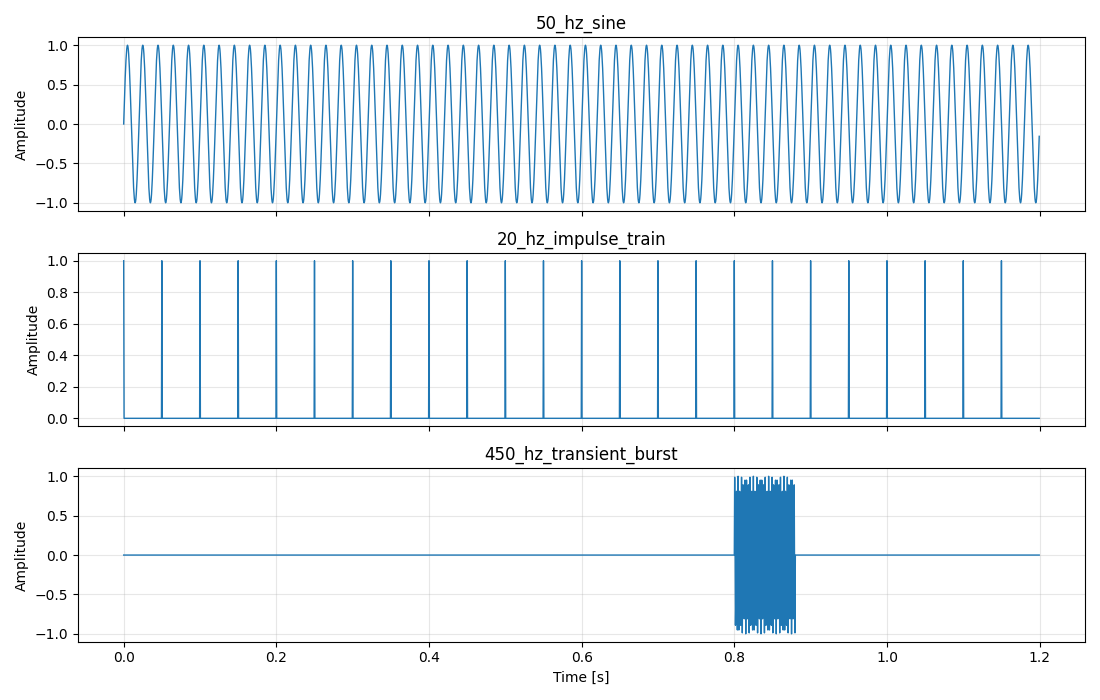

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, record in zip(axes, [base_sine, impulses, burst]):
    visible = record.values[: int(1.2 * record.sampling_rate_hz)]
    visible_time = record.time_seconds[: visible.size]
    ax.plot(visible_time, visible, linewidth=1.0)
    ax.set_title(record.name)
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Time [s]")
fig.tight_layout()

**Observation:** short bursts and impacts can have modest average energy but markedly elevated peak-sensitive metrics. **Use case:** these features help prioritize inspections for impact-like activity. **Limitation:** a peak may also be an electrical glitch or acquisition artifact.

## 4. Frequency-Domain Behavior

The FFT identifies periodic components, while Welch PSD provides a less volatile estimate of how power is distributed in frequency.

In [7]:
spectral_df = pd.DataFrame(
    [
        {
            "name": record.name,
            "dominant_frequency_hz": dominant_frequency(psd(record, nperseg=2048)),
            "centroid_hz": spectral_centroid(psd(record, nperseg=2048)),
            "bandwidth_hz": spectral_bandwidth(psd(record, nperseg=2048)),
            "rolloff_85_hz": spectral_rolloff(psd(record, nperseg=2048), rolloff_fraction=0.85),
            "flatness": spectral_flatness(psd(record, nperseg=2048)),
            "high_band_energy_300_600": band_energy(record, low_hz=300.0, high_hz=600.0),
        }
        for record in records
    ]
)
spectral_df

,name,dominant_frequency_hz,centroid_hz,bandwidth_hz,rolloff_85_hz,flatness,high_band_energy_300_600
0,50_hz_sine,49.804688,49.999386,0.590263,50.781250,3.609936e-09,2.567308e-28
1,50_hz_noisy_sine,49.804688,99.523308,170.506474,50.781250,1.050505e-01,1.765809e-02
2,50_180_hz_two_tone,49.804688,64.186374,40.538775,50.781250,5.001626e-09,1.004800e-27
3,20_hz_impulse_train,500.000000,505.044173,285.814224,859.375000,1.489709e-04,3.000000e-03
4,450_hz_transient_burst,450.195312,449.831467,29.757386,455.078125,1.716549e-02,9.922306e-03
5,bearing_like_damped_impacts,37.500000,1580.115239,1343.885997,2475.000000,1.557587e-01,3.364652e-05


Text(0.5, 1.0, 'Welch PSD comparison: known spectral changes')

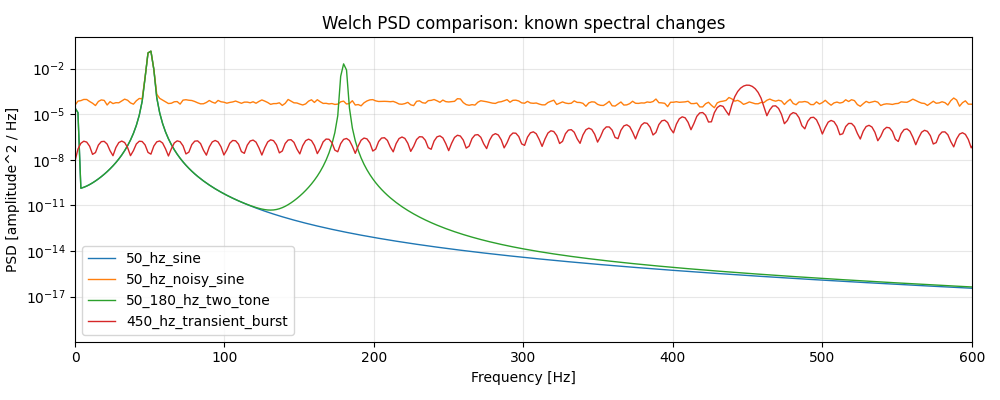

In [8]:
fig, ax = plot_frequency_spectra([base_sine, noisy_sine, two_tone, burst], spectrum_type="psd", max_frequency_hz=600.0)
ax.set_yscale("log")
ax.set_title("Welch PSD comparison: known spectral changes")

**Observation:** the two-tone spectrum exposes designed components, while the brief burst is harder to recognize in an entire-record spectrum. **Interpretation:** global spectra are useful for stable periodic structure but can dilute localized events.

## 5. Sampling And Aliasing

A sampled signal cannot distinguish frequencies above the Nyquist limit without additional information. At a sampling rate of `1000 Hz`, the Nyquist frequency is `500 Hz`; a `700 Hz` tone aliases to `300 Hz`.

,sampled_signal,described_frequency_hz,detected_fft_peak_hz
0,sampled_700_hz,700.0,300.0
1,equivalent_300_hz_alias,300.0,300.0


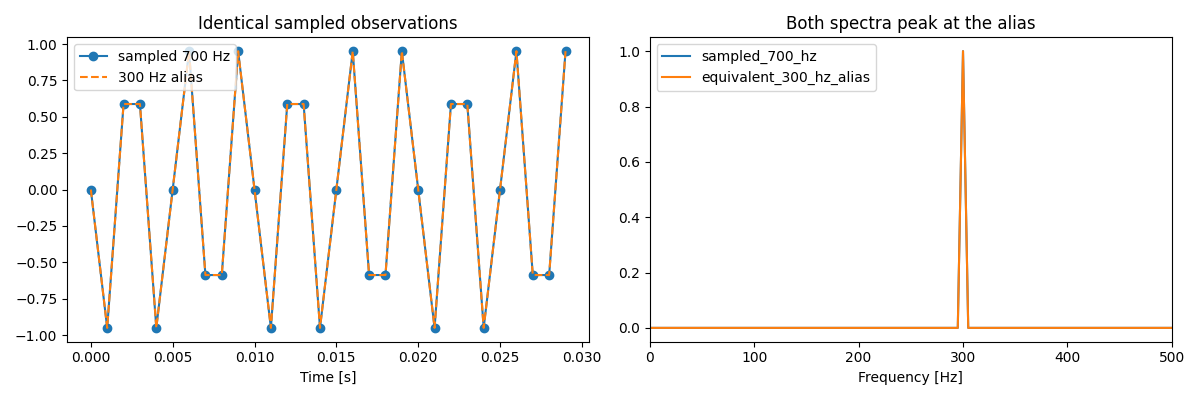

In [9]:
alias_sampling_rate_hz = 1000.0
above_nyquist = sine_wave(frequency_hz=700.0, duration_seconds=0.2, sampling_rate_hz=alias_sampling_rate_hz, name="sampled_700_hz")
equivalent_alias = sine_wave(frequency_hz=300.0, phase_radians=np.pi, duration_seconds=0.2, sampling_rate_hz=alias_sampling_rate_hz, name="equivalent_300_hz_alias")
alias_summary = pd.DataFrame(
    {
        "sampled_signal": [above_nyquist.name, equivalent_alias.name],
        "described_frequency_hz": [700.0, 300.0],
        "detected_fft_peak_hz": [dominant_frequency(fft_magnitude(above_nyquist)), dominant_frequency(fft_magnitude(equivalent_alias))],
    }
)
display(alias_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample_slice = slice(0, 30)
axes[0].plot(above_nyquist.time_seconds[sample_slice], above_nyquist.values[sample_slice], marker="o", label="sampled 700 Hz")
axes[0].plot(equivalent_alias.time_seconds[sample_slice], equivalent_alias.values[sample_slice], linestyle="--", label="300 Hz alias")
axes[0].set_title("Identical sampled observations")
axes[0].set_xlabel("Time [s]")
axes[0].legend()
for record in [above_nyquist, equivalent_alias]:
    spectrum = fft_magnitude(record)
    axes[1].plot(spectrum.frequencies_hz, spectrum.magnitudes, label=record.name)
axes[1].set_xlim(0.0, 500.0)
axes[1].set_title("Both spectra peak at the alias")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].legend()
fig.tight_layout()

**Engineering consequence:** apparent frequencies are not physically interpretable above the validated sensor and sampling bandwidth. Sampling rate and anti-alias filtering are acquisition assumptions, not cosmetic metadata.

## 6. Windowing, Leakage, And Frequency Resolution

A `53 Hz` tone is deliberately not centered on many FFT bins. Resolution is `df = sampling_rate / window_samples`. Longer windows improve frequency resolution; tapering reduces leakage at the cost of widening the main lobe.

In [10]:
leakage_record = sine_wave(frequency_hz=53.0, duration_seconds=3.0, sampling_rate_hz=2000.0, name="53_hz_non_bin_centered_sine")
leakage_rows = []
for window_seconds in [0.25, 0.50, 1.00]:
    n_samples = int(round(window_seconds * leakage_record.sampling_rate_hz))
    samples = leakage_record.values[:n_samples]
    for window_name in ["rectangular", "hann"]:
        weights = np.ones(n_samples) if window_name == "rectangular" else scipy_signal.get_window("hann", n_samples, fftbins=True)
        weights = weights / np.sqrt(np.mean(np.square(weights)))
        viewed = SignalRecord(samples * weights, leakage_record.sampling_rate_hz, name=f"{window_name}_{window_seconds}")
        nearby = band_energy(viewed, low_hz=45.0, high_hz=61.0)
        total = band_energy(viewed, low_hz=0.0, high_hz=viewed.sampling_rate_hz / 2.0)
        leakage_rows.append(
            {
                "window": window_name,
                "window_seconds": window_seconds,
                "resolution_df_hz": viewed.sampling_rate_hz / viewed.n_samples,
                "dominant_frequency_hz": dominant_frequency(fft_magnitude(viewed)),
                "spectral_bandwidth_hz": spectral_bandwidth(fft_magnitude(viewed)),
                "near_tone_energy_fraction": nearby / total,
            }
        )
leakage_table = pd.DataFrame(leakage_rows)
leakage_table

,window,window_seconds,resolution_df_hz,dominant_frequency_hz,spectral_bandwidth_hz,near_tone_energy_fraction
0,rectangular,0.25,4.0,52.0,211.501553,0.950080
1,hann,0.25,4.0,52.0,4.543718,0.999429
2,rectangular,0.50,2.0,52.0,95.363447,0.950734
3,hann,0.50,2.0,54.0,2.597403,0.999973
4,rectangular,1.00,1.0,53.0,0.000272,1.000000
5,hann,1.00,1.0,53.0,0.707107,1.000000


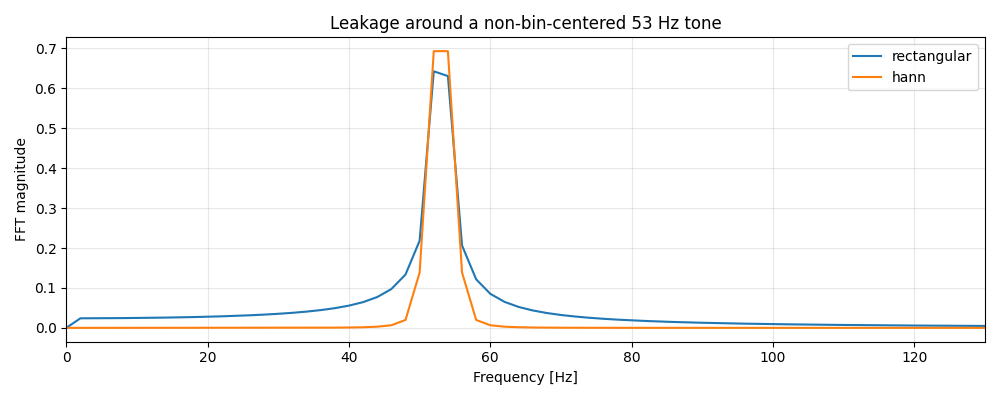

In [11]:
view_seconds = 0.50
view_samples = int(round(view_seconds * leakage_record.sampling_rate_hz))
window_values = leakage_record.values[:view_samples]
hann = scipy_signal.get_window("hann", view_samples, fftbins=True)
hann /= np.sqrt(np.mean(np.square(hann)))
rect_spectrum = fft_magnitude(window_values, sampling_rate_hz=leakage_record.sampling_rate_hz)
hann_spectrum = fft_magnitude(window_values * hann, sampling_rate_hz=leakage_record.sampling_rate_hz)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rect_spectrum.frequencies_hz, rect_spectrum.magnitudes, label="rectangular")
ax.plot(hann_spectrum.frequencies_hz, hann_spectrum.magnitudes, label="hann")
ax.set_xlim(0.0, 130.0)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("FFT magnitude")
ax.set_title("Leakage around a non-bin-centered 53 Hz tone")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

**Observation:** taper and duration change the apparent spectral spread. **Interpretation:** window choice is part of the measurement policy for band features. **Limitation:** no single window simultaneously maximizes transient timing and close-tone separation.

## 7. Time-Frequency Localization: Bearing-Like Ring-Downs

A localized bearing-like defect is represented here as repeated sharp impacts followed by short, high-frequency decaying oscillations. STFT must use one fixed time window: a short window protects event timing but coarsens frequency resolution, while a long window sharpens the resonant-band estimate but spreads each event in time. A continuous wavelet transform (CWT) evaluates many scales over the same sampled data and is useful for inspecting this localized ring-down structure.

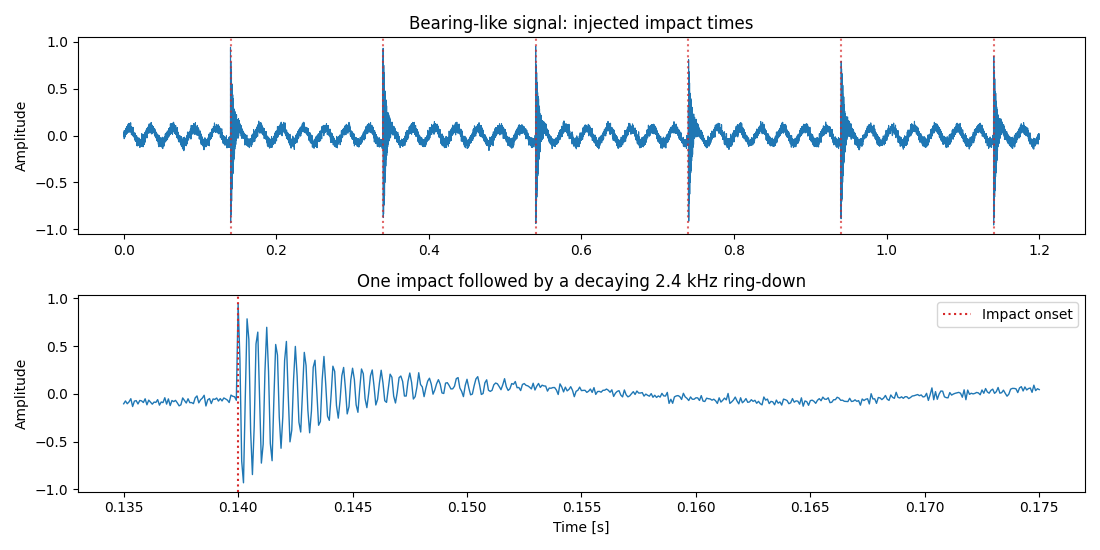

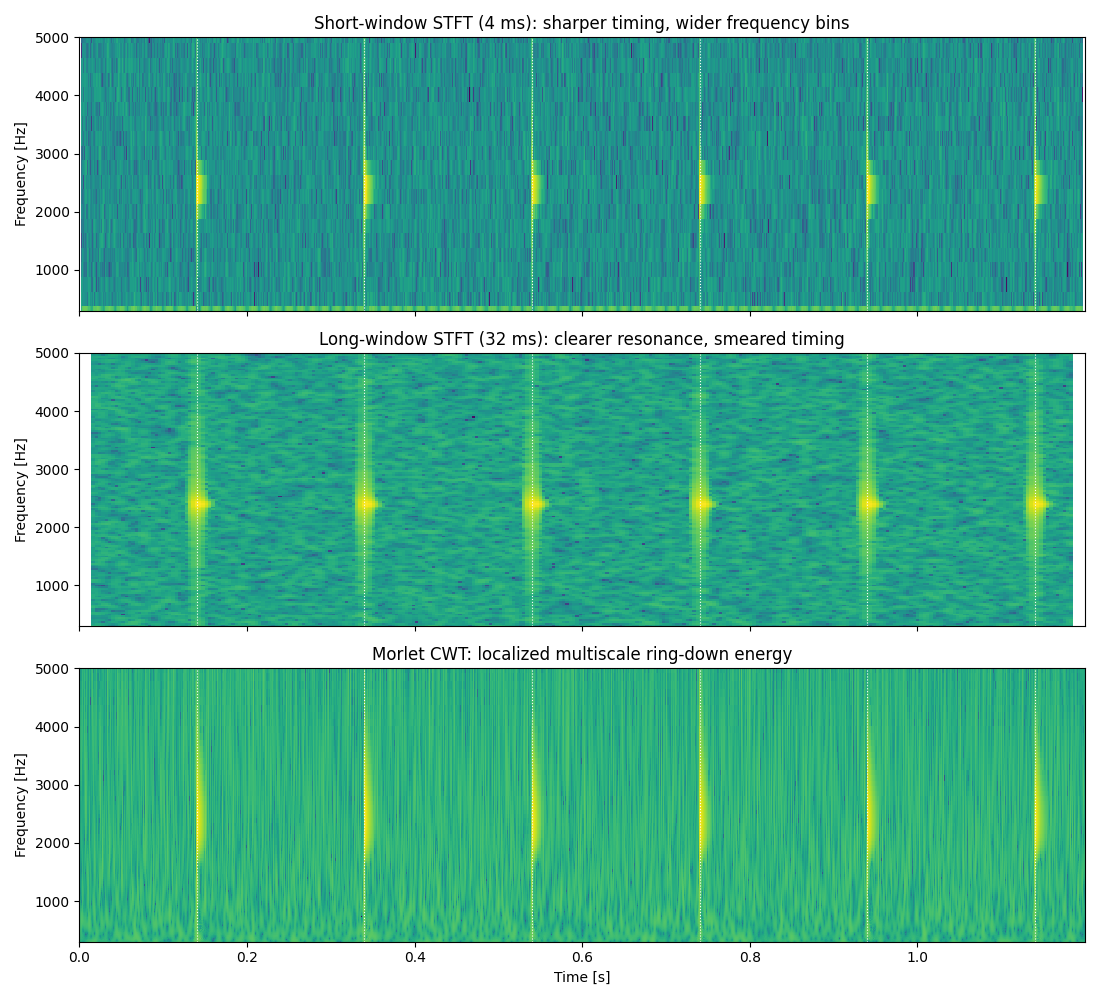

In [12]:
known_impact_times = bearing_impacts.attributes["impact_times_seconds"]
first_impact = known_impact_times[0]
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=False)
axes[0].plot(bearing_impacts.time_seconds, bearing_impacts.values, linewidth=0.8)
for impact_time in known_impact_times:
    axes[0].axvline(impact_time, color="tab:red", linestyle=":", alpha=0.7)
axes[0].set_title("Bearing-like signal: injected impact times")
axes[0].set_ylabel("Amplitude")
zoom = (bearing_impacts.time_seconds >= first_impact - 0.005) & (bearing_impacts.time_seconds <= first_impact + 0.035)
axes[1].plot(bearing_impacts.time_seconds[zoom], bearing_impacts.values[zoom], linewidth=1.0)
axes[1].axvline(first_impact, color="tab:red", linestyle=":", label="Impact onset")
axes[1].set_title("One impact followed by a decaying 2.4 kHz ring-down")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")
axes[1].legend(loc="best")
fig.tight_layout()

short_stft = stft_analysis(bearing_impacts, window_seconds=0.004, step_seconds=0.001, window="hann")
long_stft = stft_analysis(bearing_impacts, window_seconds=0.032, step_seconds=0.004, window="hann")
bearing_cwt = morlet_wavelet_scalogram(
    bearing_impacts, min_frequency_hz=300.0, max_frequency_hz=5000.0, n_frequencies=96
)
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
axes[0].pcolormesh(short_stft.times_seconds, short_stft.frequencies_hz, 20.0 * np.log10(np.maximum(short_stft.magnitude, 1e-12)), shading="auto")
axes[0].set_title("Short-window STFT (4 ms): sharper timing, wider frequency bins")
axes[1].pcolormesh(long_stft.times_seconds, long_stft.frequencies_hz, 20.0 * np.log10(np.maximum(long_stft.magnitude, 1e-12)), shading="auto")
axes[1].set_title("Long-window STFT (32 ms): clearer resonance, smeared timing")
axes[2].pcolormesh(bearing_cwt.times_seconds, bearing_cwt.frequencies_hz, 10.0 * np.log10(np.maximum(bearing_cwt.power, 1e-12)), shading="auto")
axes[2].set_title("Morlet CWT: localized multiscale ring-down energy")
for ax in axes:
    ax.set_ylim(300.0, 5000.0)
    ax.set_ylabel("Frequency [Hz]")
    for impact_time in known_impact_times:
        ax.axvline(impact_time, color="white", linestyle=":", linewidth=0.8)
axes[2].set_xlabel("Time [s]")
fig.tight_layout()

**Observation:** the two STFT settings require an explicit compromise: timing or narrowband frequency readability. The CWT is a dense visualization of how the sampled impact response occupies several scales while remaining localized in time. **Interpretation:** that makes CWT particularly useful for visual inspection of short resonant bursts; STFT remains valuable when reporting an approximate resonance frequency under a stated window policy. **Limitation:** these patterns support an impact-excited-resonance hypothesis, not a confirmed bearing diagnosis.

## 8. Discrete Wavelet Transform: Compact Impact Detection Across Scales

The DWT does not produce the same dense frequency-by-time picture as the CWT. It decomposes the sampled waveform into dyadic detail subbands. For a bearing-like impact, higher-frequency details capture the sharp onset and resonant response, so their energy can be combined into a compact event-localization score.

Detected 6 peaks from the full-record DWT score for 6 injected impacts.


,known_impact_time_seconds,nearest_detected_peak_seconds,timing_error_ms
0,0.14,0.140937,0.93750
1,0.34,0.340938,0.93750
2,0.54,0.540937,0.93750
3,0.74,0.741094,1.09375
4,0.94,0.941094,1.09375
5,1.14,1.141094,1.09375


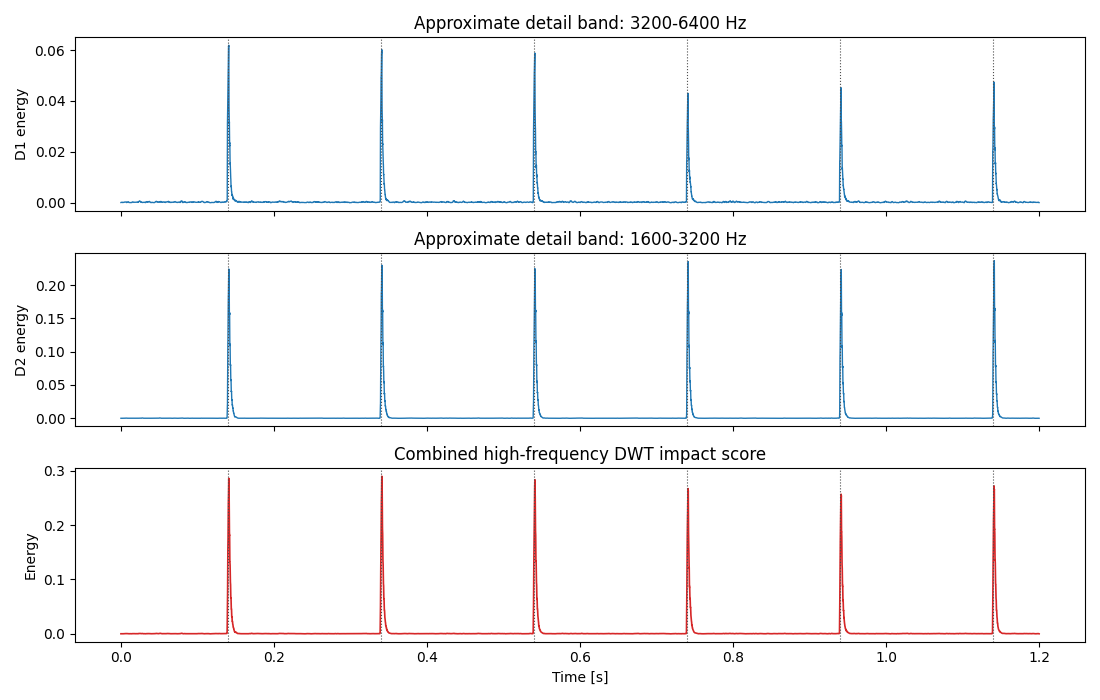

In [13]:
dwt_result = discrete_wavelet_analysis(bearing_impacts, wavelet="db4", level=5)
known_resonance_hz = bearing_impacts.attributes["resonance_frequency_hz"]
smoothing_samples = int(round(0.002 * bearing_impacts.sampling_rate_hz))
smoothing_kernel = np.ones(smoothing_samples) / smoothing_samples
smoothed_detail_energy = np.vstack(
    [scipy_signal.convolve(energy, smoothing_kernel, mode="same") for energy in dwt_result.detail_energy]
)
impact_detail_indices = [
    index
    for index, (low_hz, _high_hz) in enumerate(dwt_result.approximate_frequency_bands_hz)
    if low_hz >= 0.5 * known_resonance_hz
]
dwt_impact_score = np.sum(smoothed_detail_energy[impact_detail_indices], axis=0)

fig, axes = plt.subplots(len(impact_detail_indices) + 1, 1, figsize=(11, 7), sharex=True)
for axis, index in zip(axes, impact_detail_indices):
    low_hz, high_hz = dwt_result.approximate_frequency_bands_hz[index]
    axis.plot(dwt_result.time_seconds, smoothed_detail_energy[index], linewidth=1.0)
    axis.set_ylabel(f"D{dwt_result.detail_levels[index]} energy")
    axis.set_title(f"Approximate detail band: {low_hz:.0f}-{high_hz:.0f} Hz")
axes[-1].plot(dwt_result.time_seconds, dwt_impact_score, color="tab:red", linewidth=1.2)
axes[-1].set_title("Combined high-frequency DWT impact score")
axes[-1].set_ylabel("Energy")
axes[-1].set_xlabel("Time [s]")
for axis in axes:
    for impact_time in known_impact_times:
        axis.axvline(impact_time, color="0.3", linestyle=":", linewidth=0.8)
fig.tight_layout()

minimum_peak_distance_samples = int(round(0.10 * bearing_impacts.sampling_rate_hz))
detected_indices, _ = scipy_signal.find_peaks(
    dwt_impact_score,
    distance=minimum_peak_distance_samples,
    prominence=0.15 * np.max(dwt_impact_score),
)
detected_peak_times = dwt_result.time_seconds[detected_indices]
if detected_peak_times.size:
    nearest_peak_times = np.array(
        [detected_peak_times[np.argmin(np.abs(detected_peak_times - impact_time))] for impact_time in known_impact_times]
    )
else:
    nearest_peak_times = np.full(len(known_impact_times), np.nan)
timing_table = pd.DataFrame(
    {
        "known_impact_time_seconds": known_impact_times,
        "nearest_detected_peak_seconds": nearest_peak_times,
        "timing_error_ms": 1000.0 * (nearest_peak_times - np.asarray(known_impact_times)),
    }
)
print(f"Detected {detected_peak_times.size} peaks from the full-record DWT score for {len(known_impact_times)} injected impacts.")
timing_table


**Representation contrast:** CWT is a dense visualization for inspecting localized oscillatory structure across many scales. DWT gives a compact set of dyadic detail energies that can be combined into an impact score for detection or feature design. STFT remains the more direct representation for stating resonance frequency resolution under a fixed window. **Caveat:** the DWT band labels are approximate subbands, so the score supports event localization rather than precise carrier-frequency measurement.

## 9. Spectral Kurtosis: Selecting An Intermittent Frequency Band

Spectral kurtosis examines how unevenly short-time spectral energy is distributed over time at each frequency. A stationary component can be energetic without high excess spectral kurtosis; an intermittently excited carrier should stand out as a candidate band for later filtering or envelope analysis.


{'known_burst_frequency_hz': 420.0,
 'spectral_kurtosis_peak_frequency_hz': 420.0,
 'peak_excess_kurtosis': 8.456126524731168}

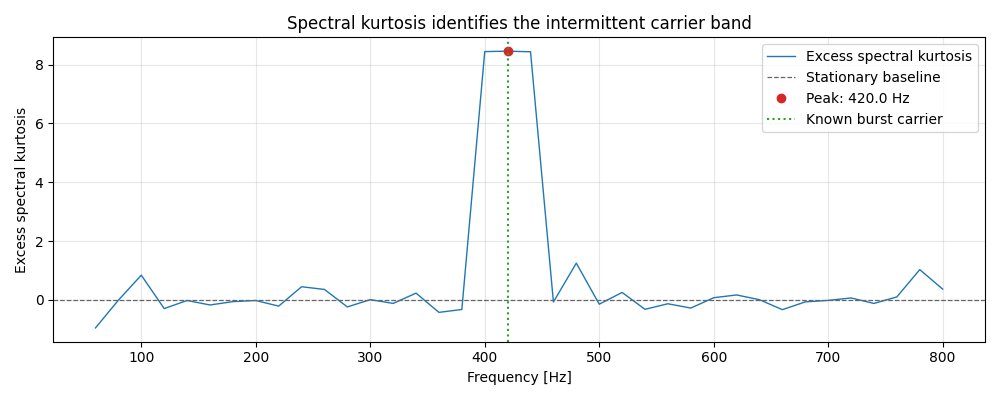

In [14]:
sk_background = noisy_sine_wave(
    frequency_hz=45.0, duration_seconds=2.0, sampling_rate_hz=2000.0, amplitude=0.08, noise_std=0.03, seed=7, name="sk_background"
)
sk_burst = transient_burst(
    duration_seconds=2.0, sampling_rate_hz=2000.0, burst_frequency_hz=420.0, burst_start_seconds=0.85, burst_duration_seconds=0.20, amplitude=1.4, name="sk_burst"
)
sk_signal = add_signals([sk_background, sk_burst], name="stationary_background_with_intermittent_resonance")
sk_result = spectral_kurtosis(
    sk_signal, window_seconds=0.05, step_seconds=0.05, min_frequency_hz=50.0, max_frequency_hz=800.0
)
fig, ax = plot_spectral_kurtosis(sk_result)
ax.axvline(420.0, color="tab:green", linestyle=":", label="Known burst carrier")
ax.set_title("Spectral kurtosis identifies the intermittent carrier band")
ax.legend(loc="best")
{
    "known_burst_frequency_hz": 420.0,
    "spectral_kurtosis_peak_frequency_hz": sk_result.peak_frequency_hz,
    "peak_excess_kurtosis": sk_result.peak_excess_kurtosis,
}


**Interpretation:** a high spectral-kurtosis frequency is evidence for an intermittently excited band, not the time of an event or a confirmed fault source. **Method choice:** the default uses non-overlapping STFT frames; overlapping frames can smooth an exploratory curve but make its independent-frame interpretation weaker. **Next step:** a justified band can be filtered before envelope analysis, TKEO, or demodulation.


## 10. Teager-Kaiser Energy And Instantaneous Frequency

The Teager-Kaiser Energy Operator (TKEO) uses adjacent samples to emphasize locally active oscillations. Here it highlights isolated impacts and a short burst without averaging energy across a long record. The DESA-2 energy-separation estimate then tracks the known frequency of a controlled narrowband chirp.

0.03178169559629396

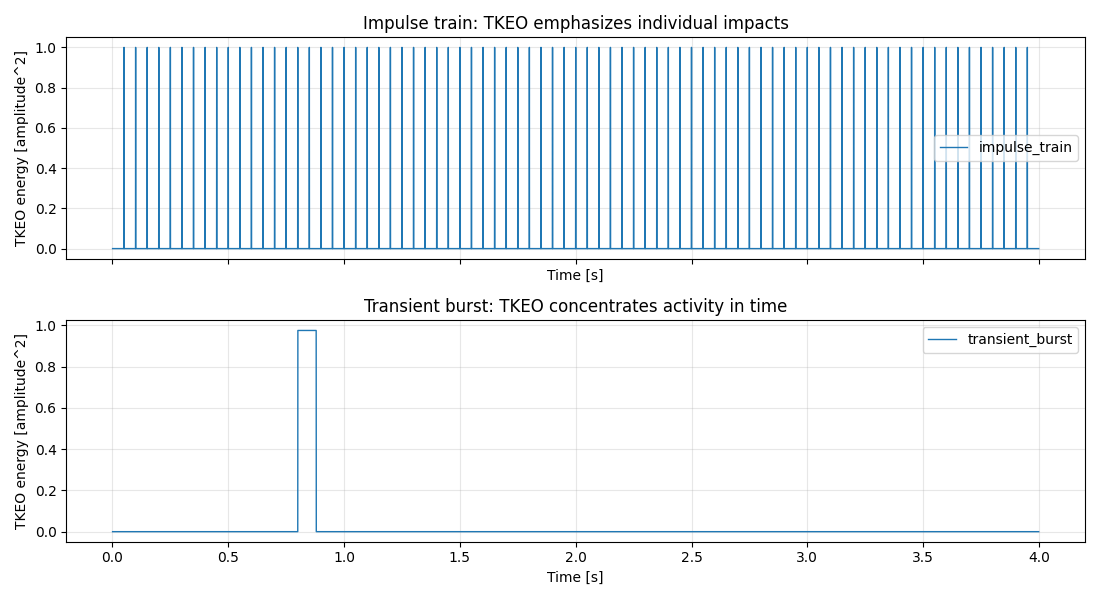

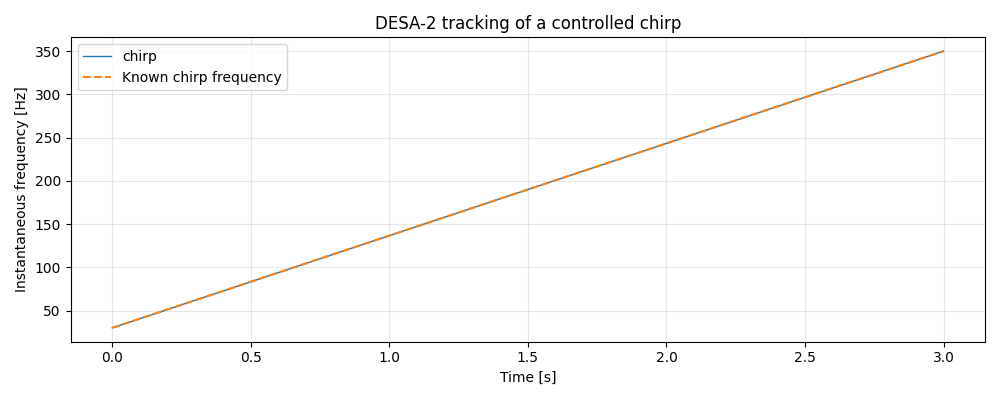

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
plot_teager_kaiser_energy(impulses, ax=axes[0])
axes[0].set_title("Impulse train: TKEO emphasizes individual impacts")
plot_teager_kaiser_energy(burst, ax=axes[1])
axes[1].set_title("Transient burst: TKEO concentrates activity in time")
fig.tight_layout()

demodulation = teager_kaiser_demodulation(chirp)
valid = demodulation.valid_mask
known_frequency_hz = (
    chirp.attributes["start_frequency_hz"]
    + (chirp.attributes["end_frequency_hz"] - chirp.attributes["start_frequency_hz"])
    * demodulation.time_seconds
    / chirp.duration_seconds
)
fig, ax = plot_teager_kaiser_frequency(chirp)
ax.plot(
    demodulation.time_seconds[valid],
    known_frequency_hz[valid],
    "--",
    label="Known chirp frequency",
)
ax.set_title("DESA-2 tracking of a controlled chirp")
ax.legend()
fig.tight_layout()

median_absolute_error_hz = float(
    np.median(np.abs(demodulation.instantaneous_frequency_hz[valid] - known_frequency_hz[valid]))
)
median_absolute_error_hz

**Interpretation:** the TKEO trace is evidence for inspection of spikes or bursts, not an automatic event decision. DESA-2 is useful for instantaneous-frequency tracking when a signal is monocomponent or explicitly narrowband and remains below one quarter of the sampling rate. **Limitation:** on mixed real signals, apply an explicit, physically justified band-pass filter before interpreting demodulated frequency.

## 11. Envelope Analysis With The Hilbert Transform

The following record is intentionally constructed as an amplitude-modulated narrowband carrier: `carrier * (1 + modulation)`. The known low-frequency modulation is the envelope we want to recover.

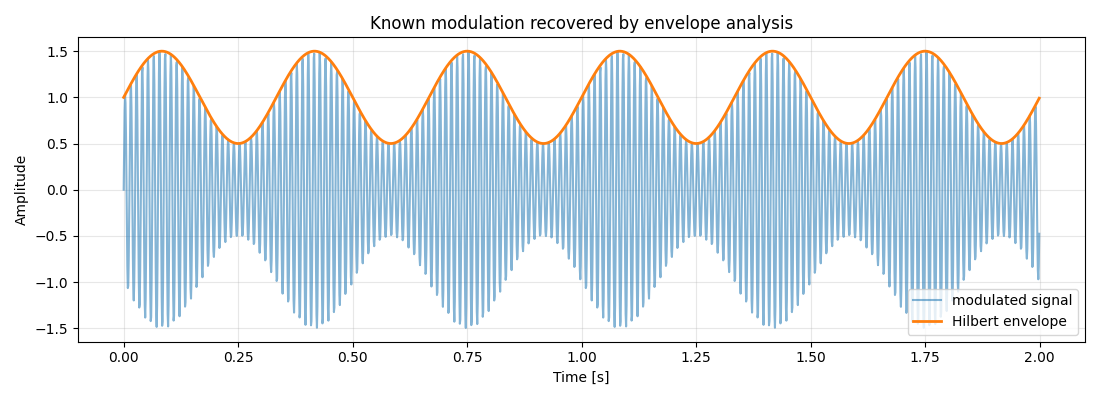

In [16]:
carrier = sine_wave(frequency_hz=80.0, duration_seconds=2.0, sampling_rate_hz=1000.0, amplitude=1.0, name="80_hz_carrier")
modulation = sine_wave(frequency_hz=3.0, duration_seconds=2.0, sampling_rate_hz=1000.0, amplitude=0.5, name="3_hz_modulation")
am_record = SignalRecord(
    values=carrier.values * (1.0 + modulation.values),
    sampling_rate_hz=carrier.sampling_rate_hz,
    label="amplitude_modulated",
    name="80_hz_carrier_with_3_hz_envelope",
    attributes={"carrier_hz": 80.0, "envelope_hz": 3.0},
)
hilbert_result = hilbert_analysis(am_record)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(am_record.time_seconds, am_record.values, label="modulated signal", alpha=0.55)
ax.plot(hilbert_result.time_seconds, hilbert_result.amplitude_envelope, label="Hilbert envelope", linewidth=2.0)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title("Known modulation recovered by envelope analysis")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

**Interpretation:** envelope analysis can expose repeated excitation of a resonant carrier, a common motivation in bearing-like diagnostics. **Limitation:** Hilbert instantaneous quantities are most defensible for narrowband or suitably filtered signals, not arbitrary broadband mixtures.

## 12. Hilbert-Huang Transform: Adaptive Modes

The Hilbert-Huang Transform first decomposes a signal into data-adaptive intrinsic mode functions (IMFs), then applies Hilbert spectral analysis to those oscillatory modes. Unlike STFT or wavelets, it does not begin with a fixed analysis basis. This flexibility helps with changing components, but the resulting modes remain empirical rather than uniquely physical.
see https://medium.com/@zeneil_writes/the-hilbert-huang-transform-letting-the-data-speak-for-itself-5c72561ee63a

### Mixed Nonstationary Components And Mode Separation

{'emd_imfs': 4,
 'ceemdan_imfs': 4,
 'ceemdan_reconstruction_max_error': 4.440892098500626e-16}

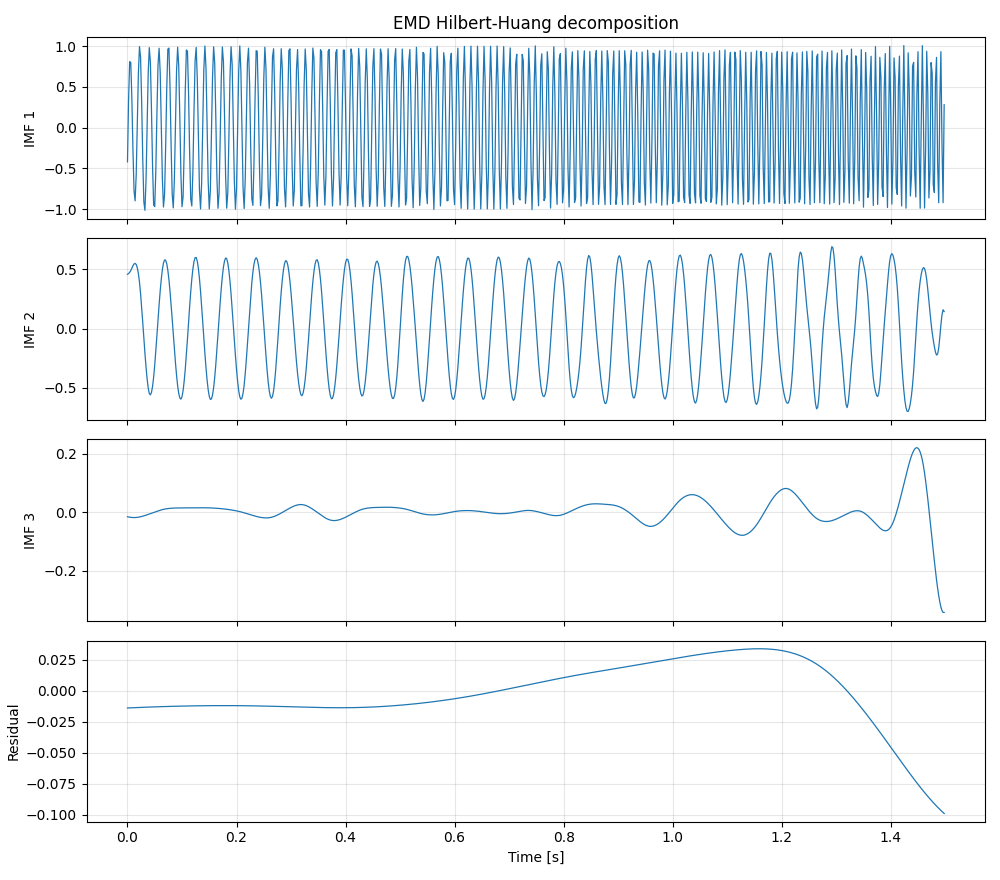

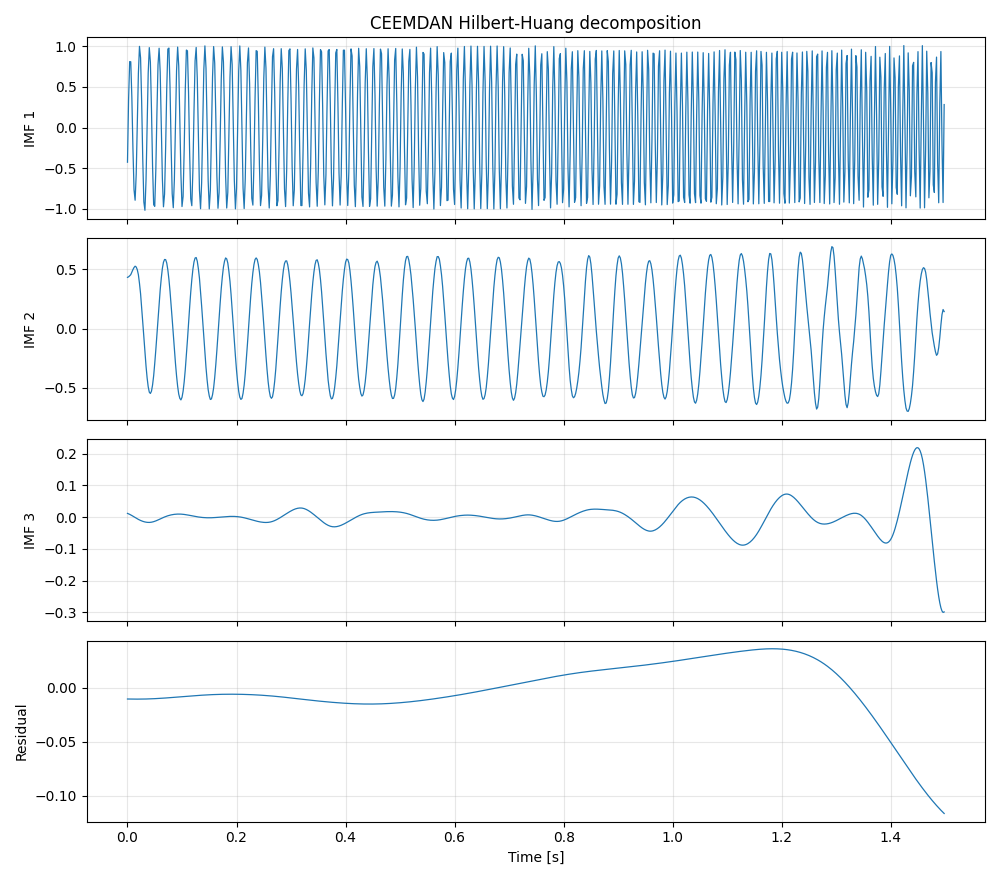

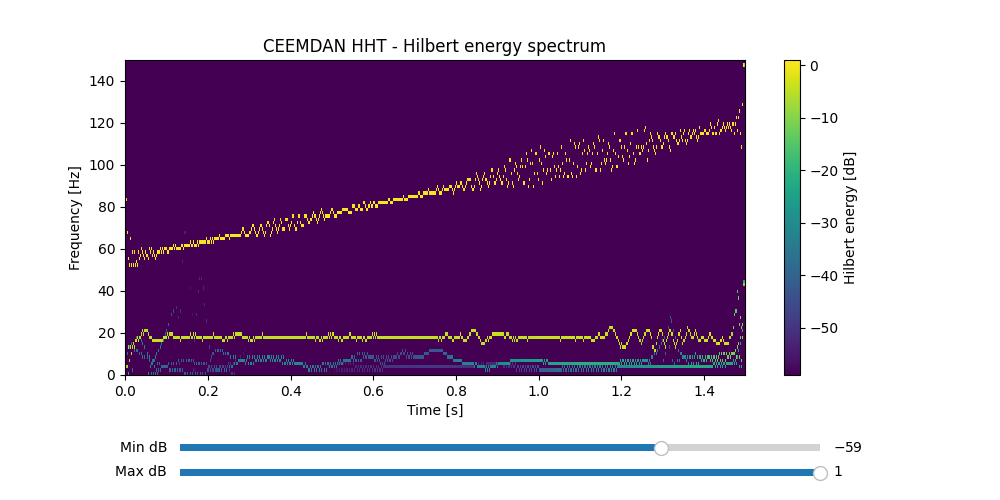

In [17]:
hht_sampling_rate_hz = 500.0
hht_duration_seconds = 1.5
hht_low_tone = sine_wave(frequency_hz=18.0, duration_seconds=hht_duration_seconds, sampling_rate_hz=hht_sampling_rate_hz, amplitude=0.6, name="hht_low_tone")
hht_chirp = chirp_signal(start_frequency_hz=55.0, end_frequency_hz=120.0, duration_seconds=hht_duration_seconds, sampling_rate_hz=hht_sampling_rate_hz, amplitude=1.0, name="hht_chirp")
hht_mixed = add_signals([hht_low_tone, hht_chirp], name="hht_mixed_nonstationary_components")

emd_hht = hilbert_huang_transform(hht_mixed, method="emd", max_imfs=4, n_frequency_bins=96, max_frequency_hz=150.0)
ceemdan_hht = hilbert_huang_transform(
    hht_mixed,
    method="ceemdan",
    max_imfs=4,
    n_frequency_bins=96,
    max_frequency_hz=150.0,
    ceemdan_trials=10,
    random_state=0,
)

plot_hilbert_huang_imfs(emd_hht, max_imfs=3)
plot_hilbert_huang_imfs(ceemdan_hht, max_imfs=3)
plot_hilbert_huang_spectrum(ceemdan_hht, dynamic_range_db=60.0)
{
    "emd_imfs": emd_hht.intrinsic_mode_functions.shape[0],
    "ceemdan_imfs": ceemdan_hht.intrinsic_mode_functions.shape[0],
    "ceemdan_reconstruction_max_error": float(np.max(np.abs(ceemdan_hht.intrinsic_mode_functions.sum(axis=0) + ceemdan_hht.residual - hht_mixed.values))),
}

**Interpretation:** EMD offers the canonical HHT decomposition; CEEMDAN adds controlled noise ensembles to mitigate mode mixing when activity at different scales competes for the same IMF. **Limitation:** CEEMDAN is slower and its output depends on its seed and trial policy; neither method proves that an IMF corresponds to one physical component.

### Localized Transient Evidence

Text(0.5, 1.0, 'HHT burst-band view: localized high-frequency activity')

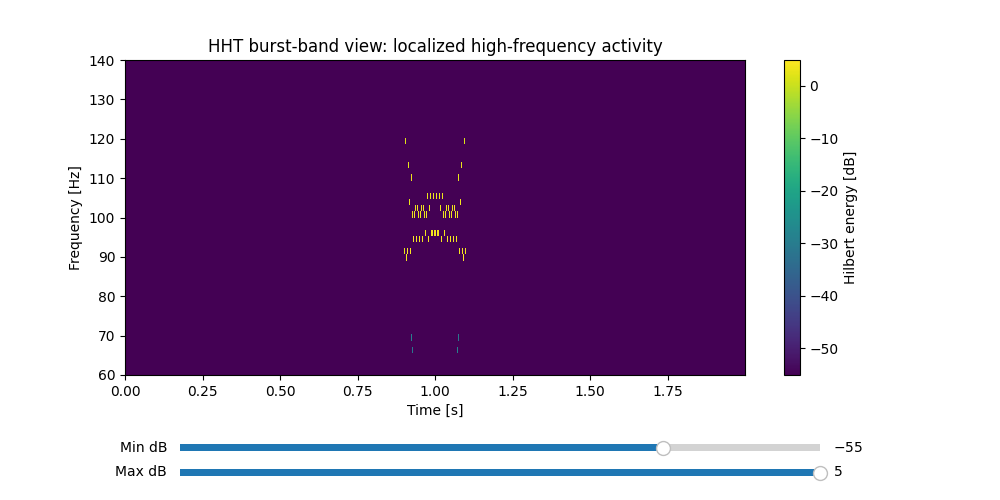

In [18]:
hht_baseline = sine_wave(frequency_hz=20.0, duration_seconds=2.0, sampling_rate_hz=500.0, amplitude=0.15, name="hht_baseline")
hht_event = transient_burst(duration_seconds=2.0, sampling_rate_hz=500.0, burst_frequency_hz=100.0, burst_start_seconds=0.9, burst_duration_seconds=0.2, amplitude=1.5, name="hht_burst")
hht_transient = add_signals([hht_baseline, hht_event], name="hht_baseline_with_burst")
hht_transient_result = hilbert_huang_transform(hht_transient, method="emd", max_imfs=5, n_frequency_bins=96, max_frequency_hz=150.0)

fig, ax = plot_hilbert_huang_spectrum(hht_transient_result, dynamic_range_db=60.0)
ax.set_ylim(60.0, 140.0)
ax.set_title("HHT burst-band view: localized high-frequency activity")

**Interpretation:** the burst-band Hilbert spectrum provides adaptive time-frequency evidence consistent with the earlier TKEO and spectrogram views. **Limitation:** endpoint effects can be strong in HHT, and an IMF is an adaptive mathematical mode, not a diagnosed fault source without supporting physics and metadata.

## 13. Editable Exploration Cell

Change these plain variables and rerun the cell to explore how acquisition rate, noise, burst duration, analysis window, and frequency-band choice affect an interpretable result.

,window_start_seconds,window_end_seconds,band_energy_chosen_band
19,0.95,1.15,0.413139
18,0.90,1.10,0.265921
20,1.00,1.20,0.130730
17,0.85,1.05,0.031044
24,1.20,1.40,0.016352


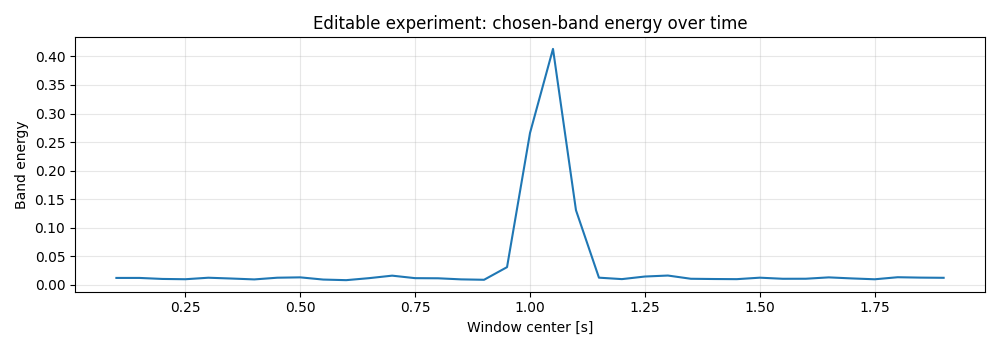

In [19]:
noise_std = 0.20
burst_duration_seconds = 0.08
analysis_window_seconds = 0.20
exploration_sampling_rate_hz = 2000.0
frequency_band_hz = (300.0, 600.0)

exploration = noisy_sine_wave(frequency_hz=50.0, duration_seconds=2.0, sampling_rate_hz=exploration_sampling_rate_hz, noise_std=noise_std, seed=2, name="editable_baseline")
event = transient_burst(duration_seconds=2.0, sampling_rate_hz=exploration_sampling_rate_hz, burst_frequency_hz=450.0, burst_start_seconds=1.0, burst_duration_seconds=burst_duration_seconds, amplitude=1.0, name="editable_event")
combined = SignalRecord(exploration.values + event.values, exploration_sampling_rate_hz, name="editable_combination")
safe_high_hz = min(frequency_band_hz[1], exploration_sampling_rate_hz / 2.0)
config = SlidingWindowConfig(
    window_seconds=analysis_window_seconds,
    step_seconds=analysis_window_seconds / 4.0,
    frequency_bands=(FrequencyBand("chosen_band", frequency_band_hz[0], safe_high_hz),),
)
exploration_features = FeatureExtractor().extract_windows(combined, config).to_dataframe()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(exploration_features["window_center_seconds"], exploration_features["band_energy_chosen_band"])
ax.set_title("Editable experiment: chosen-band energy over time")
ax.set_xlabel("Window center [s]")
ax.set_ylabel("Band energy")
ax.grid(True, alpha=0.3)
fig.tight_layout()
exploration_features.nlargest(5, "band_energy_chosen_band")[["window_start_seconds", "window_end_seconds", "band_energy_chosen_band"]]

## 14. Method-Selection Summary

| Observation type | Useful representation | Interpretable feature | Main caveat |
| --- | --- | --- | --- |
| Stable periodic tone | FFT or PSD | dominant frequency, band energy | requires validated sampling and sufficient duration |
| Broadband/noisy texture | PSD | flatness, bandwidth | affected by acquisition noise |
| Short resonant impact: visual inspection | CWT scalogram | localized multiscale wavelet energy | dense view is descriptive, not a detector or precise spectrum |
| Short resonant impact: event scoring | DWT detail energies | multiscale impact score | detail bands are approximate frequency ranges |
| Short impact or burst | TKEO or spectrogram | local energy trace, local RMS, crest factor | transient cause is not identified automatically |
| Intermittently excited frequency band | Spectral kurtosis | peak excess spectral kurtosis and peak frequency | depends on STFT window policy and indicates a band, not event timing |
| Changing narrowband component | STFT, wavelet, or DESA-2 | time-varying frequency trajectory | DESA-2 requires a defensible narrowband component below one quarter of the sampling rate |
| Narrowband amplitude modulation | Envelope analysis | envelope spectrum or amplitude trend | requires a defensible carrier band |
| Nonstationary multiscale oscillations | HHT (EMD or CEEMDAN) | adaptive IMF trajectories and Hilbert energy spectrum | mode mixing, endpoint effects, and CEEMDAN runtime or seed policy affect interpretation |

The next walkthrough applies these ideas to a single long record without revealing the injected synthetic event until after candidate regions have been identified.